🕵️ Fake Job Posting Detector

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('fake_job_postings.csv.zip')

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [5]:
df.shape

(17880, 18)

In [6]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [8]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

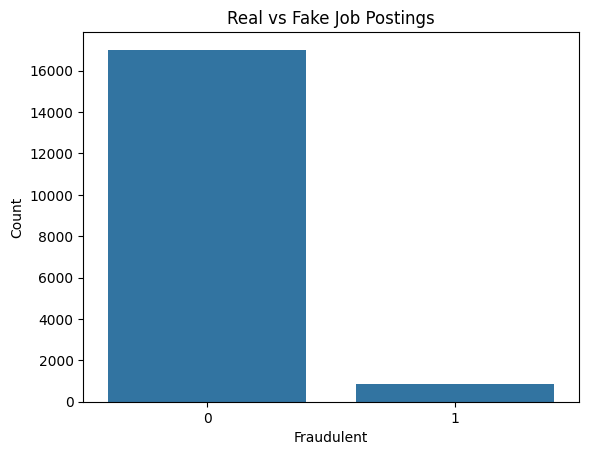

In [10]:

sns.countplot(x="fraudulent", data=df)

plt.title("Real vs Fake Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()

In [11]:
df["industry"].value_counts().head(10)

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Name: count, dtype: int64

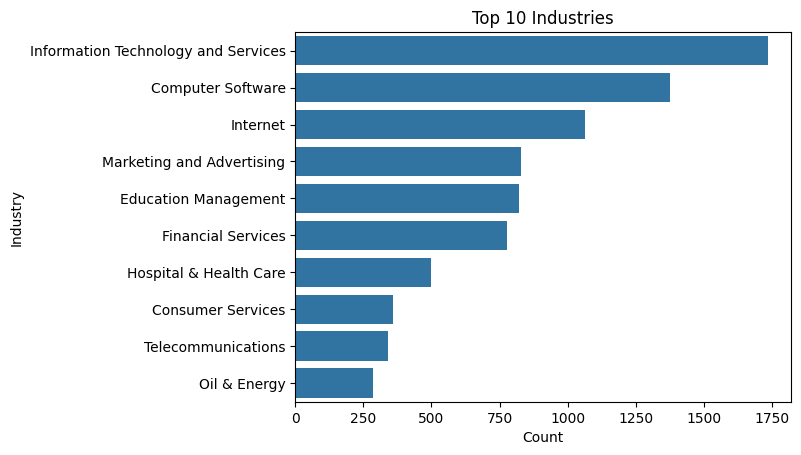

In [12]:
top_industry = df["industry"].value_counts().head(10)

sns.barplot(x=top_industry.values, y=top_industry.index)

plt.title("Top 10 Industries")
plt.xlabel("Count")
plt.ylabel("Industry")
plt.show()

In [13]:
df["employment_type"].value_counts()

employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

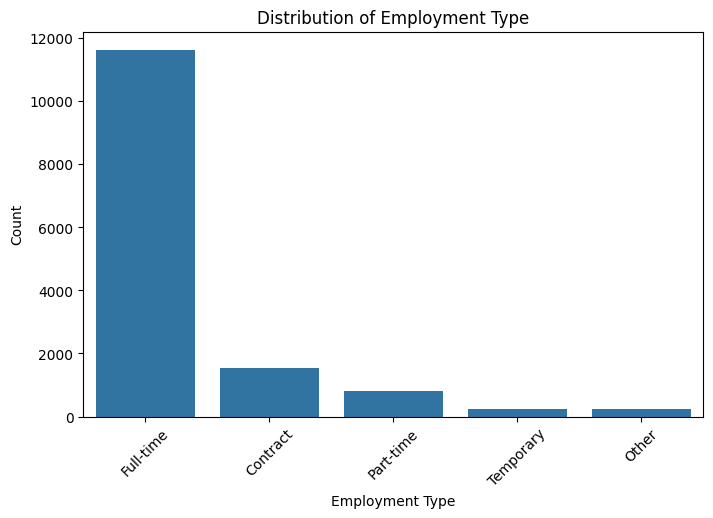

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="employment_type",
    order=df["employment_type"].value_counts().index
)

plt.title("Distribution of Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [15]:
pd.crosstab(df["employment_type"], df["fraudulent"])

fraudulent,0,1
employment_type,,
Contract,1480,44
Full-time,11130,490
Other,212,15
Part-time,723,74
Temporary,239,2


In [16]:
pd.crosstab(
    df["employment_type"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876


In [17]:
df["required_experience"].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

In [18]:
pd.crosstab(
    df["required_experience"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
required_experience,,
Associate,98.171528,1.828472
Director,95.629820,4.370180
Entry level,93.362996,6.637004
Executive,92.907801,7.092199
Internship,97.375328,2.624672
Mid-Senior level,97.033342,2.966658
Not Applicable,94.623656,5.376344


In [19]:
df.select_dtypes(include="number").columns

Index(['job_id', 'telecommuting', 'has_company_logo', 'has_questions',
       'fraudulent'],
      dtype='str')

In [20]:
for col in ["telecommuting", "has_company_logo", "has_questions"]:
    print("\n", col)
    print(
        pd.crosstab(
            df[col],
            df["fraudulent"],
            normalize="index"
        ) * 100
    )


 telecommuting
fraudulent             0         1
telecommuting                     
0              95.313504  4.686496
1              91.655802  8.344198

 has_company_logo
fraudulent                0          1
has_company_logo                      
0                 84.071038  15.928962
1                 98.009845   1.990155

 has_questions
fraudulent             0         1
has_questions                     
0              93.221831  6.778169
1              97.156506  2.843494


In [21]:
text_cols = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_cols:
    print(col, df[col].isnull().sum())

title 0
company_profile 3308
description 1
requirements 2696
benefits 7212


In [22]:
df["benefits"] = df["benefits"].fillna("")

In [23]:
df["description_length"] = df["description"].fillna("").str.len()

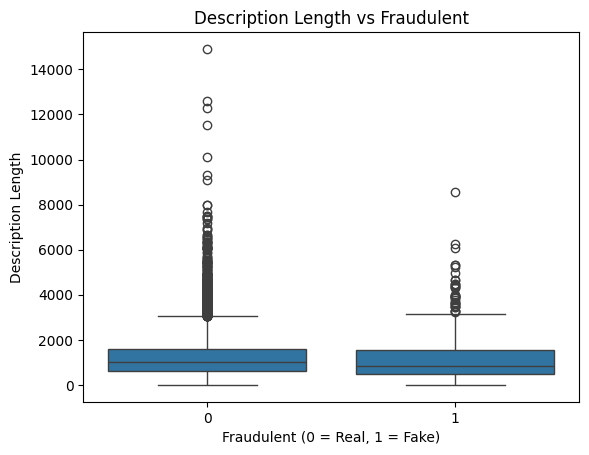

In [24]:
sns.boxplot(
    data=df,
    x="fraudulent",
    y="description_length"
)

plt.title("Description Length vs Fraudulent")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Description Length")
plt.show()

In [25]:
df["description_word_count"] = (
    df["description"]
    .fillna("")
    .str.split()
    .str.len()
)

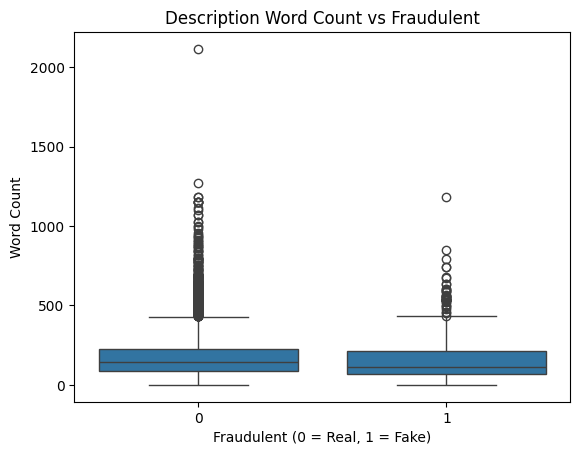

In [26]:
sns.boxplot(
    data=df,
    x="fraudulent",
    y="description_word_count"
)

plt.title("Description Word Count vs Fraudulent")
plt.xlabel("Fraudulent (0 = Real, 1 = Fake)")
plt.ylabel("Word Count")
plt.show()

In [27]:
df = df.drop("job_id", axis=1)

In [28]:
df.shape

(17880, 19)

In [29]:
df.isnull().sum().sort_values(ascending=False)

salary_range              15012
department                11547
required_education         8105
required_experience        7050
function                   6455
industry                   4903
employment_type            3471
company_profile            3308
requirements               2696
location                    346
description                   1
title                         0
has_company_logo              0
telecommuting                 0
benefits                      0
has_questions                 0
fraudulent                    0
description_length            0
description_word_count        0
dtype: int64

In [32]:
df.shape

(17880, 19)